In [1]:
# Importation des bibliothèques nécessaires
import pandas as pd              # manipulation des données
import numpy as np               # calcul numérique
import matplotlib.pyplot as plt  # visualisation
import seaborn as sns            # visualisation avancée

# Affichage des graphiques directement dans Jupyter
%matplotlib inline

In [2]:
# Charger le dataset (consommation des voitures)
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

dataSet = pd.read_csv(url)

# Renommer les colonnes pour correspondre au TP
dataSet = dataSet.rename(columns={
    "mpg": "MPG",
    "cylinders": "Cylinders",
    "displacement": "Displacement",
    "horsepower": "Horsepower",
    "weight": "Weight",
    "acceleration": "Acceleration",
    "model_year": "Model Year",
    "origin": "Origin"
})

# Supprimer les valeurs manquantes
dataSet = dataSet.dropna()

# Afficher les 5 premières lignes
dataSet.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [3]:
# Afficher le nombre de lignes et de colonnes
dataSet.shape

(392, 9)

In [4]:
# Vérifier les valeurs nulles
dataSet.isnull().sum()

MPG             0
Cylinders       0
Displacement    0
Horsepower      0
Weight          0
Acceleration    0
Model Year      0
Origin          0
name            0
dtype: int64

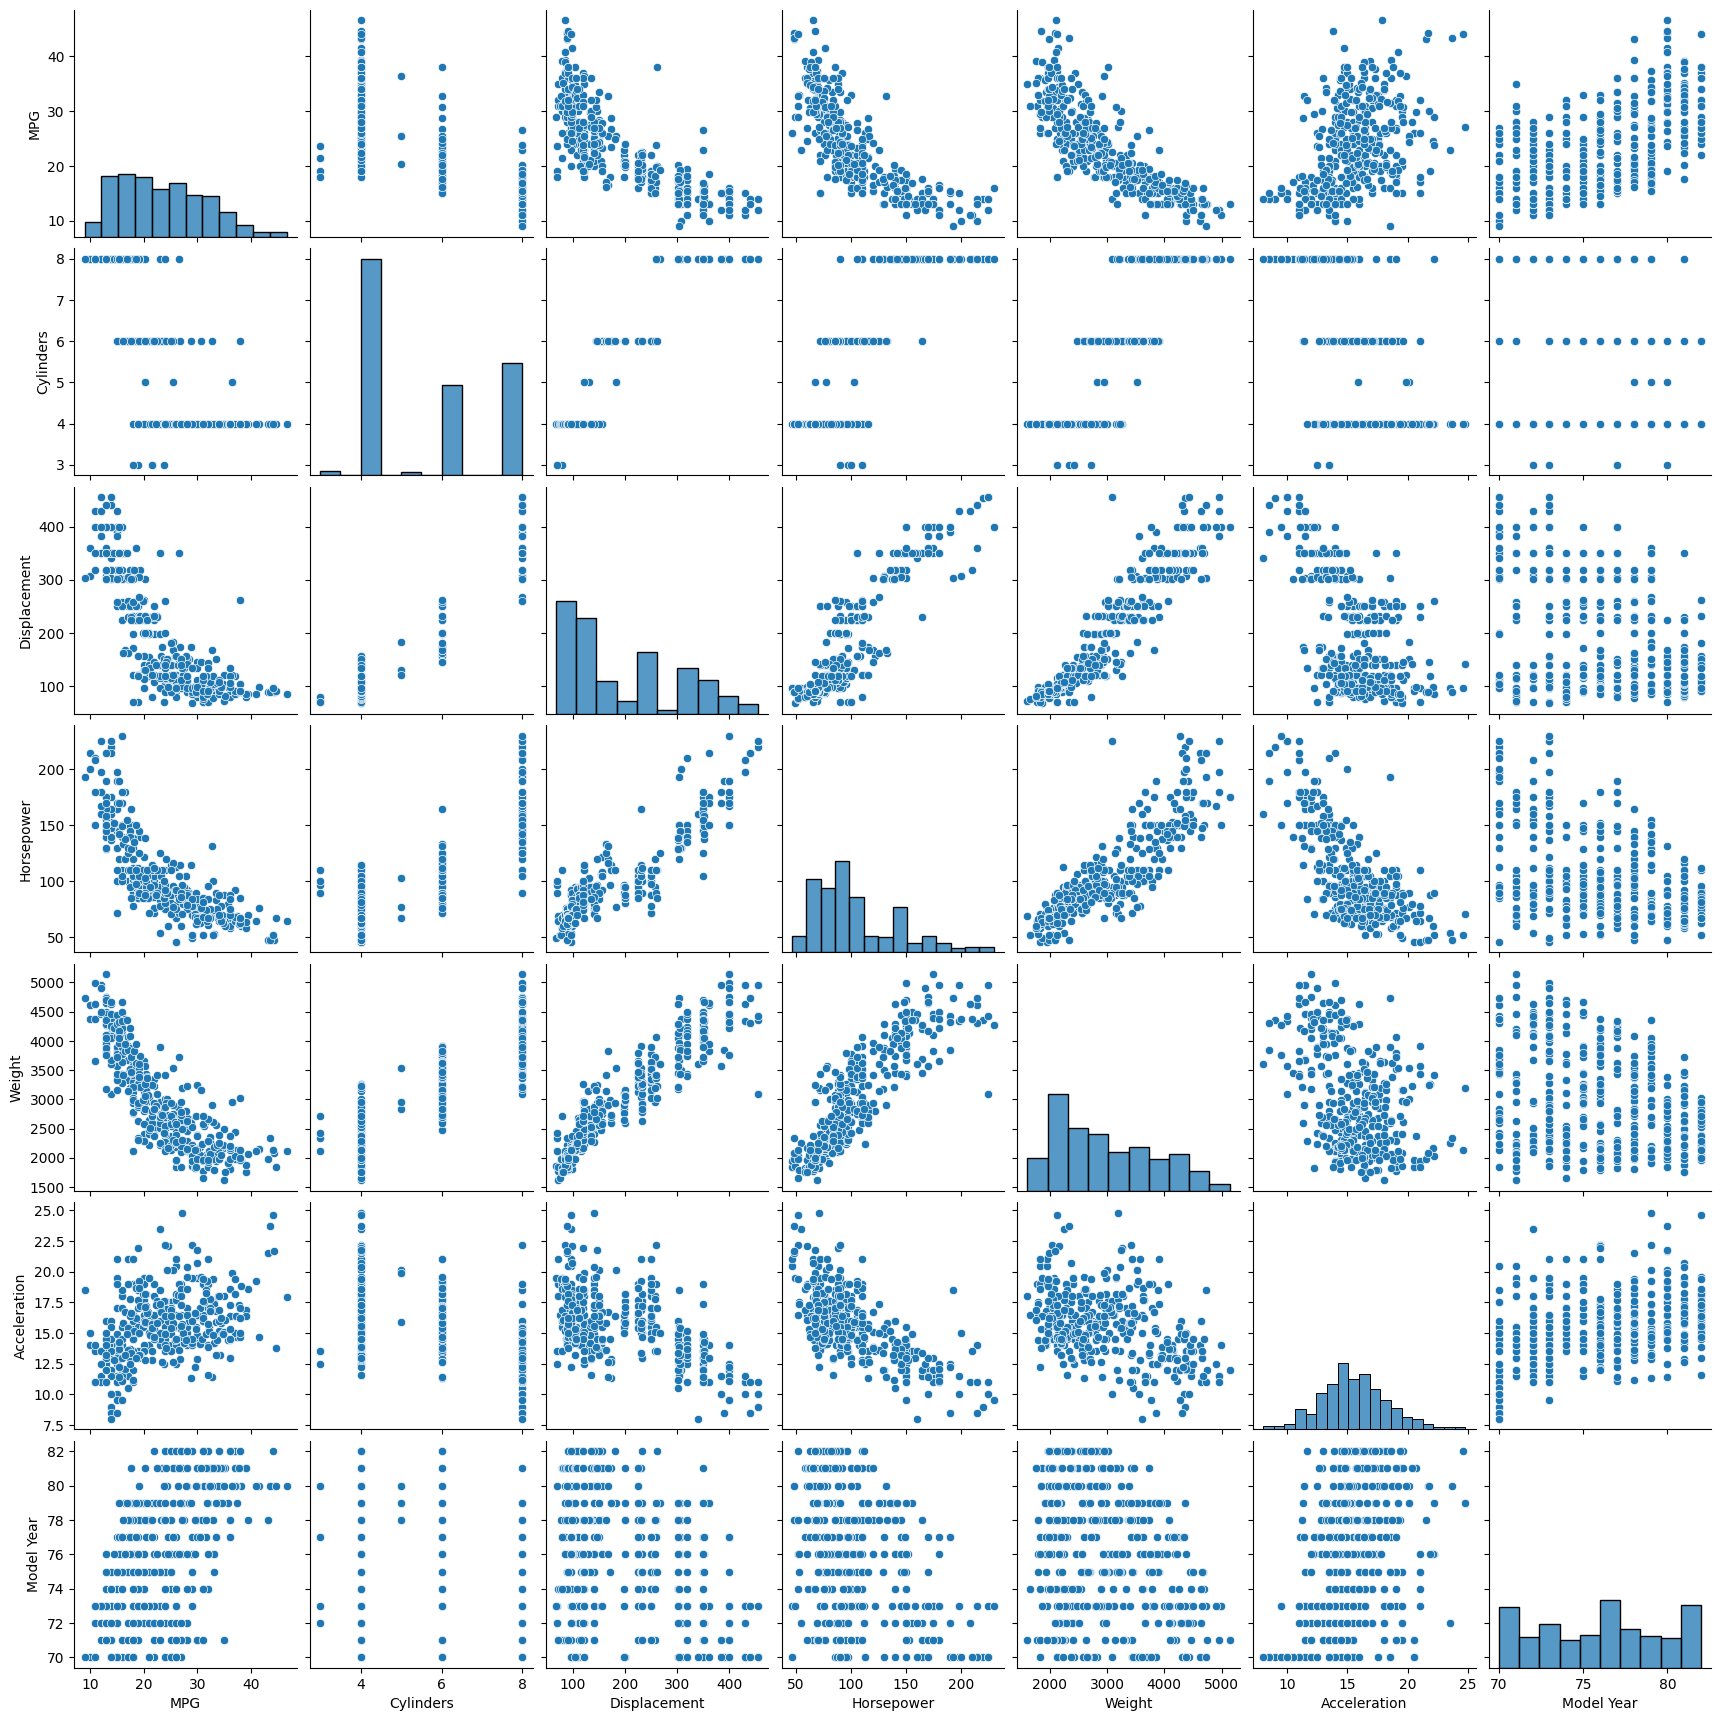

In [5]:
# Visualiser les relations entre toutes les variables
sns.pairplot(dataSet)

plt.show()

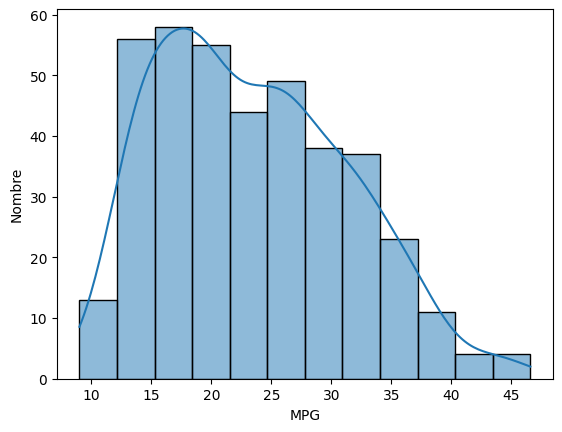

In [6]:
# Histogramme de la variable cible MPG
sns.histplot(dataSet["MPG"], kde=True)

plt.xlabel("MPG")
plt.ylabel("Nombre")

plt.show()

In [7]:
# Calcul de la matrice de corrélation
cor = dataSet.corr(numeric_only=True)

# Afficher la matrice
cor

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year
MPG,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541
Cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647
Displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855
Horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361
Weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120
Acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316
Model Year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000


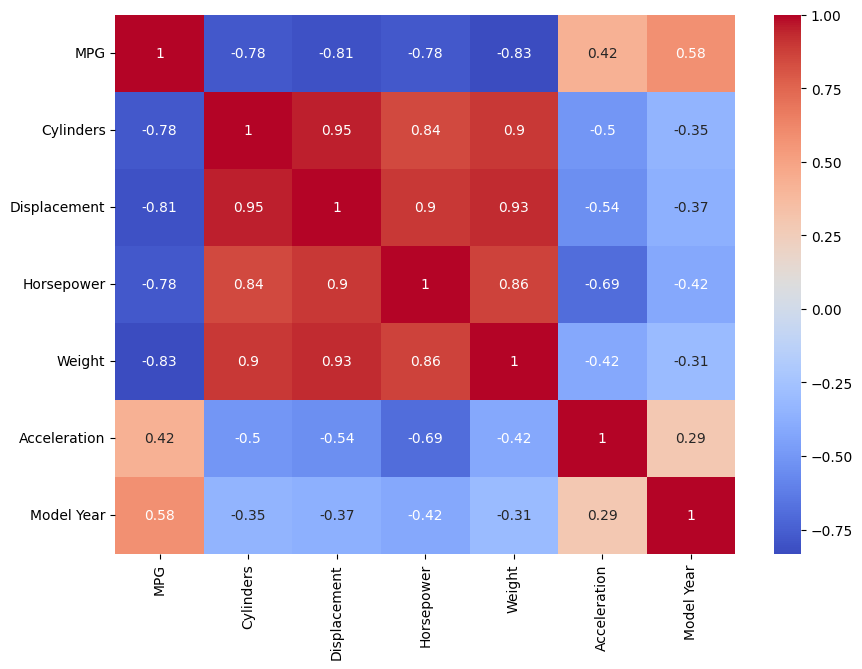

In [8]:
# Visualisation de la corrélation avec heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(cor, annot=True, cmap="coolwarm")

plt.show()

In [9]:
from sklearn.model_selection import train_test_split

# Variables explicatives (X)
X = dataSet.drop("MPG", axis=1)

# Transformer la variable "Origin" en variables numériques
X = pd.get_dummies(X, drop_first=True)

# Variable cible (Y)
Y = dataSet["MPG"]

# Division en données d'entraînement et de test (70% / 30%)
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=20
)
X_train.head()

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin_japan,Origin_usa,name_amc ambassador dpl,name_amc ambassador sst,...,name_volvo 145e (sw),name_volvo 244dl,name_volvo 245,name_volvo 264gl,name_volvo diesel,name_vw dasher (diesel),name_vw pickup,name_vw rabbit,name_vw rabbit c (diesel),name_vw rabbit custom
21,4,107.0,90.0,2430,14.5,70,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
213,8,350.0,145.0,4055,12.0,76,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
34,6,225.0,105.0,3439,15.5,71,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
85,8,350.0,175.0,4100,13.0,73,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
88,8,302.0,137.0,4042,14.5,73,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
X_train.dtypes

Cylinders                      int64
Displacement                 float64
Horsepower                   float64
Weight                         int64
Acceleration                 float64
                              ...   
name_vw dasher (diesel)         bool
name_vw pickup                  bool
name_vw rabbit                  bool
name_vw rabbit c (diesel)       bool
name_vw rabbit custom           bool
Length: 308, dtype: object

In [12]:
from sklearn.linear_model import LinearRegression

In [14]:
# Création du modèle de régression linéaire
lin_model = LinearRegression()

# Entraînement
lin_model.fit(X_train, Y_train)

# Prédictions
predictions = lin_model.predict(X_test)

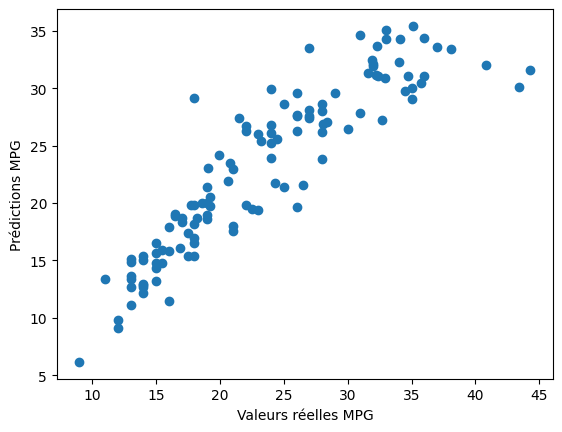

In [15]:
# Comparaison valeurs réelles vs prédictions
plt.scatter(Y_test, predictions)

plt.xlabel("Valeurs réelles MPG")
plt.ylabel("Prédictions MPG")

plt.show()

Partie 2 : Régression Logistique

In [16]:
# Charger le dataset (admission des étudiants)
url2 = "https://stats.idre.ucla.edu/stat/data/binary.csv"

dataset = pd.read_csv(url2)

# Renommer les colonnes
dataset.columns = ["admit", "gre", "gpa", "prestige"]

dataset.head()

,admit,gre,gpa,prestige
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

dummy_ranks = pd.get_dummies(dataset["prestige"], prefix="prestige")

data = dataset[["admit", "gre", "gpa"]].join(dummy_ranks)

x = data.drop("admit", axis=1)
y = data["admit"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=1
)

logmodel = LogisticRegression(C=1e20, max_iter=1000)
logmodel.fit(x_train, y_train)

y_pred = logmodel.predict(x_test)

count_misclassified = (y_test != y_pred).sum()
accuracy = accuracy_score(y_test, y_pred)

print("Échantillons mal classés :", count_misclassified)
print("Précision :", round(accuracy, 2))

Échantillons mal classés : 31
Précision : 0.74


In [18]:
dataset.shape

(400, 4)

In [19]:
dataset.isnull().sum()

admit       0
gre         0
gpa         0
prestige    0
dtype: int64

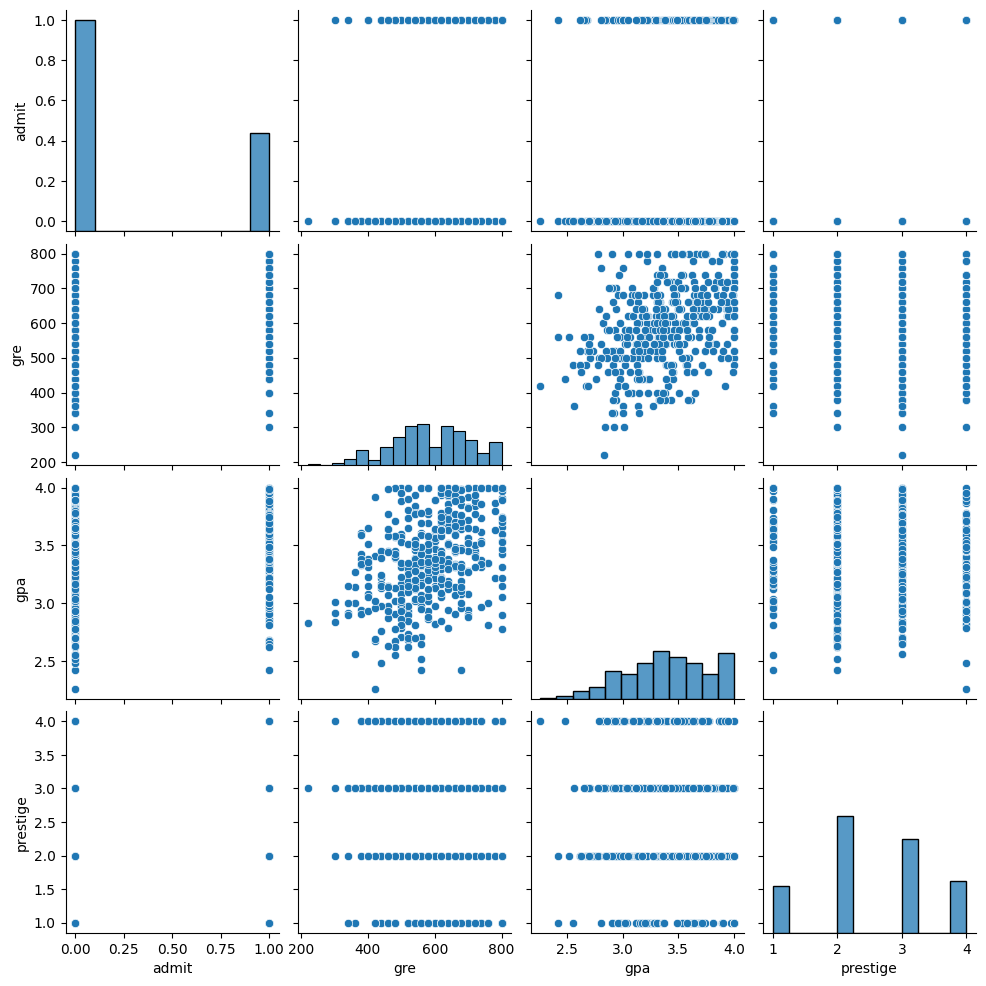

In [20]:
# Visualisation des relations
sns.pairplot(dataset)

plt.show()

In [21]:
# Transformer "prestige" en variables numériques
dummy_ranks = pd.get_dummies(dataset["prestige"], prefix="prestige")

# Créer un nouveau dataset
data = dataset[["admit", "gre", "gpa"]].join(dummy_ranks)

data.head()

,admit,gre,gpa,prestige_1,prestige_2,prestige_3,prestige_4
0,0,380,3.61,False,False,True,False
1,1,660,3.67,False,False,True,False
2,1,800,4.00,True,False,False,False
3,1,640,3.19,False,False,False,True
4,0,520,2.93,False,False,False,True


In [22]:
# Nombre d'étudiants admis / non admis
data["admit"].value_counts()

admit
0    273
1    127
Name: count, dtype: int64

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Variables
x = data.drop("admit", axis=1)
y = data["admit"]

# Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=1
)

# Création du modèle
logmodel = LogisticRegression(C=1e20, max_iter=1000)

# Entraînement
logmodel.fit(x_train, y_train)

# Prédiction
y_pred = logmodel.predict(x_test)

In [24]:
# Nombre d'erreurs
count_misclassified = (y_test != y_pred).sum()

# Précision
accuracy = accuracy_score(y_test, y_pred)

print("Échantillons mal classés :", count_misclassified)
print("Précision :", round(accuracy, 2))

Échantillons mal classés : 31
Précision : 0.74
